In [24]:
import sys

sys.path.append('../')
import pandas as pd
import pyomo.environ as pyo
import tensorflow.keras as keras
from omlt import OffsetScaling, OmltBlock
from omlt.io.keras import load_keras_sequential
from omlt.neuralnet import (
    FullSpaceNNFormulation,
    FullSpaceSmoothNNFormulation,
    NetworkDefinition,
    ReducedSpaceSmoothNNFormulation,
    ReluBigMFormulation,
    ReluComplementarityFormulation,
    ReluPartitionFormulation,
)
from pyomo.opt import SolverFactory

from src.ewenpyomo import ewen_model
from src.neural_network import create_nn, data_scaling
from src.omlt_model import create_model


__OMLT__

In [25]:
# Data loading
df = pd.read_csv('../data/datasetcost_v4.csv')
df.rename(columns={'cost1': 'Total_Cost1',
                   'cost2': 'Total_Cost2',
                   'cost3':'Total_Cost3',
                   'totalcost':'total_cost'}, inplace=True)

# Modeling using ONLY the total_cost
df.drop(columns=['Total_Cost1', 'Total_Cost2', 'Total_Cost3'], inplace=True)

inputs = list(df.columns)
inputs.remove('total_cost')
outputs = ['total_cost']

print(f'Dataset shape: {df.shape}')

Dataset shape: (1000, 7)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 1/5000
84/84 - 1s - loss: 1.0199 - val_loss: 0.9841 - 1s/epoch - 13ms/step
Epoch 2/5000
84/84 - 0s - loss: 1.0090 - val_loss: 0.9812 - 254ms/epoch - 3ms/step
Epoch 3/5000
84/84 - 0s - loss: 1.0079 - val_loss: 0.9782 - 292ms/epoch - 3ms/step
Epoch 4/5000
84/84 - 0s - loss: 0.9994 - val_loss: 0.9811 - 274ms/epoch - 3ms/step
Epoch 5/5000
84/84 - 0s - loss: 0.9933 - val_loss: 0.9699 - 297ms/epoch - 4ms/step
Epoch 6/5000
84/84 - 0s - loss: 0.9790 - val_loss: 0.9711 - 249ms/epoch - 3ms/step
Epoch 7/5000
84/84 - 0s - loss: 0.9737 - val_loss: 0.9598 - 290ms/epoch - 3ms/step
Epoch 8/5000
84/84 - 0s - loss: 0.9687 - val_loss: 0.9700 - 300ms/epoch - 4ms/step
Epoch 9/5000
84/84 - 0s - loss: 0.9532 - val_loss: 0.9500 - 257ms/epoch - 3ms/step
Epoch 10/5000
84/84 - 0s - loss: 0.9387 - val_loss: 0.9547 - 228ms/epoch - 3ms/step
Epoch 11/5000
84/84 - 0s - loss: 0.9314 - val_loss: 0.9475 - 293ms/epoch - 3ms/step

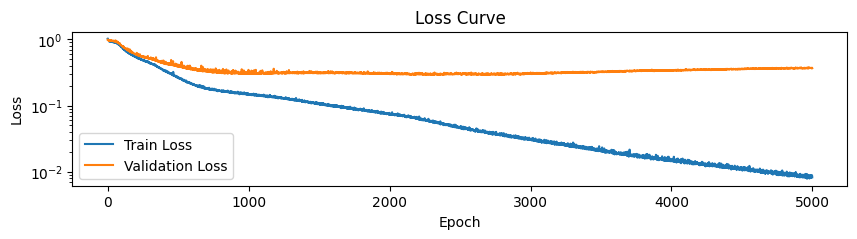

In [26]:
%load_ext autoreload
%autoreload

# Data scaling
x, y, x_offset, x_factor, \
    y_offset, y_factor, scaled_lb, scaled_ub = data_scaling(df, inputs, outputs)
    
# Create and train a ANN
net = create_nn(x, y)

In [34]:
omlt_model = pyo.ConcreteModel()
omlt_model.cost = OmltBlock()
nn_cost = keras.models.load_model('cost_nn.keras', compile=False)

scaler = OffsetScaling(
    offset_inputs={i: x_offset[inputs[i]] for i in range(len(inputs))},
    factor_inputs={i: x_factor[inputs[i]] for i in range(len(inputs))},
    offset_outputs={i: y_offset[outputs[i]] for i in range(len(outputs))},
    factor_outputs={i: y_factor[outputs[i]] for i in range(len(outputs))},
)

scaled_input_bounds = {i: (scaled_lb[i], scaled_ub[i]) for i in range(len(inputs))}

net = load_keras_sequential(
    nn_cost, scaling_object=scaler, scaled_input_bounds=scaled_input_bounds
)
omlt_model.cost.build_formulation(FullSpaceSmoothNNFormulation(net))


In [28]:
# Load ewen basic model
ewen_pyomo_model = ewen_model()

# Create merged model
model = pyo.ConcreteModel()
model.model1 = ewen_pyomo_model
model.model2 = omlt_model

In [29]:
cost = outputs.index('total_cost')

# Create objective function
model.obj = pyo.Objective(expr=model.model1.EFTotal + 0.0001 * model.model2.cost.outputs[cost], sense=pyo.minimize)

In [30]:
FiR_1 = inputs.index('Fir1')
FiR_2 = inputs.index('Fir2')
FiR_3 = inputs.index('Fir3')
CiR_1 = inputs.index('Cir1')
CiR_2 = inputs.index('Cir2')
CiR_3 = inputs.index('Cir3')

model.constraint1 = pyo.Constraint(expr=model.model1.FiR[1] == model.model2.cost.inputs[FiR_1])
model.constraint2 = pyo.Constraint(expr=model.model1.FiR[2] == model.model2.cost.inputs[FiR_2])
model.constraint3 = pyo.Constraint(expr=model.model1.FiR[3] == model.model2.cost.inputs[FiR_3])

model.constraint4 = pyo.Constraint(expr=model.model1.CiR[1] == model.model2.cost.inputs[CiR_1])
model.constraint5 = pyo.Constraint(expr=model.model1.CiR[2] == model.model2.cost.inputs[CiR_2])
model.constraint6 = pyo.Constraint(expr=model.model1.CiR[3] == model.model2.cost.inputs[CiR_3])

In [31]:
solver = pyo.SolverFactory('ipopt')
results = solver.solve(model, tee=False)

In [32]:
print(f'EFTotal value: {model.obj()}')
print(f'cost value: {model.model2.cost.outputs[cost].value}')
print(f'ERTotal value: {model.model1.ERTotal()}')
print(f'interc value: {model.model1.interc()}')
print()
print(f'FiR_1 = {model.model1.FiR[1].value}')
print(f'FiR_2 = {model.model1.FiR[2].value}')
print(f'FiR_3 = {model.model1.FiR[3].value}')
print()
print(f'CiR_1 = {model.model1.CiR[1].value}')
print(f'CiR_2 = {model.model1.CiR[2].value}')
print(f'CiR_3 = {model.model1.CiR[3].value}')
print()
print(f'CoR_1 = {model.model1.CoR[1].value}')
print(f'CoR_2 = {model.model1.CoR[2].value}')
print(f'CoR_3 = {model.model1.CoR[3].value}')

EFTotal value: 132.21229083157317
cost value: -77855.1640275012
ERTotal value: 220.00000219521152
interc value: 28.0

FiR_1 = 60.89355424543268
FiR_2 = 41.335996653663265
FiR_3 = 117.77045129611557

CiR_1 = 9134.033122405346
CiR_2 = 6715.217593716187
CiR_3 = 13628.105720331238

CoR_1 = 1217.8710850985549
CoR_2 = 413.3599666317505
CoR_3 = 1177.7045130562738


__List model constraints__

In [33]:
# Print all constraints of model.model2
for i in model.model2.cost.component_objects(pyo.Constraint, active=True):
    print(f'Constraint: {i}')
    i.pprint()

Constraint: model2.cost._scale_input_constraint
_scale_input_constraint : Size=6, Index=model2.cost.inputs_set, Active=True
    Key : Lower : Body                                                                                           : Upper : Active
      0 :   0.0 :    model2.cost.scaled_inputs[0] - (model2.cost.inputs[0] - 98.05131066402672)/58.4274723894972 :   0.0 :   True
      1 :   0.0 :  model2.cost.scaled_inputs[1] - (model2.cost.inputs[1] - 15210.519155376109)/8765.696802094673 :   0.0 :   True
      2 :   0.0 : model2.cost.scaled_inputs[2] - (model2.cost.inputs[2] - 100.48114522071796)/58.134839099409575 :   0.0 :   True
      3 :   0.0 :  model2.cost.scaled_inputs[3] - (model2.cost.inputs[3] - 14711.251433623984)/8594.680330559862 :   0.0 :   True
      4 :   0.0 :   model2.cost.scaled_inputs[4] - (model2.cost.inputs[4] - 98.82106451234421)/57.36198866357421 :   0.0 :   True
      5 :   0.0 :   model2.cost.scaled_inputs[5] - (model2.cost.inputs[5] - 14953.93467565729)/8